# qPCR Sample Analysis Pipeline

**Gabi Rivera**
*June 25, 2026*

### Phase I — Import and Validation

---

### Imported Libraries

In [39]:
import pandas as pd
import numpy as np

from pathlib import Path

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install klib

import klib

## Load QuantStudio 5 Dataset

### GitHub Repository

In [40]:
# Clone the GitHub Repository (Colab only)
if IN_COLAB:
    !git clone https://github.com/GabiRivera0011/resiDNA_workflows.git

In [41]:
# Set the project path
if IN_COLAB:
    project_path = Path("/content/resiDNA_workflows")
else:
    # Running locally: cwd is usually Notebooks/, repo root is its parent
    project_path = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()

data_path = project_path / "Data"
notebook_path = project_path / "Notebooks"

print(project_path)

/Users/gabirivera/Desktop/Github/resiDNA_workflows


In [42]:
# Verify the Data exist
list(data_path.iterdir())

[PosixPath('/Users/gabirivera/Desktop/Github/resiDNA_workflows/Data/experiment_001.xlsx'),
 PosixPath('/Users/gabirivera/Desktop/Github/resiDNA_workflows/Data/.gitkeep'),
 PosixPath('/Users/gabirivera/Desktop/Github/resiDNA_workflows/Data/sample_data_001.xls'),
 PosixPath('/Users/gabirivera/Desktop/Github/resiDNA_workflows/Data/sample_data_002.xls')]

In [ ]:
#@markdown ## Select Dataset
SOURCE_FILE = "experiment_001.xlsx" #@param {type:"string"}

# QuantStudio exports as .xlsx (openpyxl) or the legacy .xls (xlrd) — pandas needs
# the engine spelled out rather than guessed, so pick it from the extension here once
file = data_path / SOURCE_FILE
EXCEL_ENGINE = "xlrd" if file.suffix.lower() == ".xls" else "openpyxl"

xls = pd.ExcelFile(file, engine=EXCEL_ENGINE)
xls.sheet_names


### Dataset = df

In [ ]:
# Read the desired worksheet or tab
df = pd.read_excel(
    file,
    sheet_name="Results",
    header=22,
    engine=EXCEL_ENGINE
)

### Table Styling Helper

In [45]:
# Consistent, presentation-ready styling for all tables in this notebook
# Colors are explicit so tables render in light mode regardless of the editor/notebook theme
def style_table(data, caption="", hide_index=True, precision=2, align="center",
                highlight_rows=None, highlight_color="#D4EDDA", precision_overrides=None):
    styler = data.style.set_caption(caption)

    if highlight_rows is not None:
        def _highlight(row):
            if highlight_rows.loc[row.name]:
                return [f"background-color: {highlight_color} !important"] * len(row)
            return [""] * len(row)

        styler = styler.apply(_highlight, axis=1)

    if hide_index:
        styler = styler.hide(axis="index")

    styler = styler.format(precision=precision, na_rep="—")

    # Per-column precision overrides (e.g. Total DNA / Protein Concentration / DNA per
    # Protein always render at 4 decimals, regardless of this table's default precision)
    if precision_overrides:
        for col, col_precision in precision_overrides.items():
            if col in data.columns:
                styler = styler.format(precision=col_precision, na_rep="—", subset=[col])

    styler = styler.set_table_attributes(
        'style="background-color:#FFFFFF; border-collapse:collapse;"'
    )

    styler = styler.set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-size", "13pt"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("padding", "4px 0 8px 0"),
            ("color", "#2C3E50"),
            ("background-color", "#FFFFFF"),
        ]},
        {"selector": "th", "props": [
            ("background-color", "#2C3E50"),
            ("color", "#FFFFFF"),
            ("font-weight", "bold"),
            ("text-align", align),
            ("padding", "6px 12px"),
            ("border", "1px solid #2C3E50"),
        ]},
        {"selector": "td", "props": [
            ("padding", "6px 12px"),
            ("border", "1px solid #DDDDDD"),
            ("text-align", align),
            ("color", "#2C2C2C"),
            ("background-color", "#FFFFFF"),
        ]},
        {"selector": "tr:nth-child(even) td", "props": [
            ("background-color", "#F7F9FA"),
        ]},
    ])

    return styler

# Total DNA / Protein Concentration / DNA per Protein always render at 4 decimals
# wherever they appear (Final Sample Results tables), regardless of the table's
# default precision
FINAL_RESULTS_PRECISION = {
    "Total DNA (ng/mL)": 4,
    "Protein Concentration (mg/mL)": 4,
    "DNA per Protein (ng/mg)": 4,
}

# Shared renderer for the "Item / Criteria / Value / Status" suitability summary
# tables (System Suitability, Sample Suitability) — Fail rows highlighted red
def style_criteria_summary(rows, caption):
    summary_table = pd.DataFrame(rows)
    return style_table(
        summary_table,
        caption=caption,
        align="left",
        highlight_rows=summary_table["Status"] == "Fail",
        highlight_color="#F8D7DA",
    )

# Renders one group's criteria rows as its own styled table, so System/Sample
# Suitability show one table per group instead of one long combined table.
# Skipped with a note if a run has nothing to evaluate for that group (e.g. no
# ERC/PC controls)
from IPython.display import display

def display_criteria_group(rows, caption):
    if rows:
        display(style_criteria_summary(rows, caption=caption))
    else:
        print(f"{caption}: no criteria evaluated for this run.")

# Renders a "wide" suitability table (one row per item, each criterion as its own
# Value/Pass column pair) instead of one row per item×criterion. Skipped with a note
# if the underlying data is empty for this run
def display_wide_table(data, caption, fail_mask=None):
    if len(data):
        display(style_table(
            data,
            caption=caption,
            align="left",
            highlight_rows=fail_mask,
            highlight_color="#F8D7DA",
        ))
    else:
        print(f"{caption}: no criteria evaluated for this run.")

### MetaData

In [ ]:
# Capture Metadata
metadata_df = pd.read_excel(
    file,
    sheet_name="Results",
    header=None,
    nrows=19,
    engine=EXCEL_ENGINE
)

# Keep only the first two columns (Field and Value)
metadata_table = metadata_df.iloc[:, :2].copy()

# Rename columns
metadata_table.columns = ["Field", "Value"]

# Remove completely empty rows
metadata_table = metadata_table.dropna(how="all")

# Display the table
style_table(metadata_table, caption="Experiment Metadata", align="left")

### Regression Line Info

In [ ]:
# Regression Line
regression_df = pd.read_excel(
    file,
    sheet_name="Results",
    header=None,
    skiprows=18,
    nrows=1,
    usecols="C:G",
    engine=EXCEL_ENGINE
)

# Convert to a tidy DataFrame
regression_stats = []

for item in regression_df.iloc[0]:
    if pd.notna(item):
        key, value = str(item).split(":", 1)
        regression_stats.append({
            "Metric": key.strip(),
            "Value": value.strip()
        })

regression_table = pd.DataFrame(regression_stats)

style_table(regression_table, caption="Standard Curve Regression Statistics", align="left")

### Exploratory Data Analysis

In [48]:
# Dataset Table
style_table(df.head(), caption="Raw Dataset Preview (Results Sheet)")

Well,Well Position,Task,Sample Name,Target Name,Ct,Ct Mean,Ct CV%,Ct SD,Quantity,Quantity Mean,Quantity SD,Quantity %CV,Dilution Factor,Dilution Adjusted,% Recovery,R2,Slope,Y-Intercept,Total DNA per mL,Total DNA per Protein Concentration,Flag,Ct Threshold,Automatic Ct Threshold,CQ Confidence,Automatic Baseline,Baseline Start,Baseline End,Reference,Reference Adjusted,Spike Input,Back calculated value,Back Calculation Mean,Back Calculation %CV,Back Calculation SD,Back Calculation % difference,Back Calculation % difference Mean,Fit,Amplification Efficiency,Amplification Status,AMPNC,NOAMP,EXPFAIL,Protein Concentration,CQCONF
A1,1,NTC,NTC,CHO,Undetermined,—,—,—,—,—,—,—,1.00,—,—,1.00,-3.30,21.32,0.00,—,0.00,0.21,True,0.00,Yes,3.00,39.00,—,—,0.00,—,—,—,—,—,—,Linear,100.89,No Amp,N,N,N,—,N
A2,2,NTC,NTC,CHO,Undetermined,—,—,—,—,—,—,—,1.00,—,—,1.00,-3.30,21.32,0.00,—,0.00,0.21,True,0.00,Yes,3.00,39.00,—,—,0.00,—,—,—,—,—,—,Linear,100.89,No Amp,N,N,N,—,N
A3,3,NTC,NTC,CHO,Undetermined,—,—,—,—,—,—,—,1.00,—,—,1.00,-3.30,21.32,0.00,—,0.00,0.21,True,0.00,Yes,3.00,39.00,—,—,0.00,—,—,—,—,—,—,Linear,100.89,No Amp,N,N,N,—,N
A4,4,UNKNOWN,S1 D1,CHO,32.36,32.52,0.81,0.26,0.00,0.00,0.00,17.24,1.00,0.00,—,1.00,-3.30,21.32,0.00,0.00,0.00,0.21,True,1.00,Yes,3.00,27.00,0.00,0.00,0.00,—,—,—,—,—,—,Linear,100.89,Amplification,N,N,N,1.82,N
A5,5,UNKNOWN,S1 D1,CHO,32.37,32.52,0.81,0.26,0.00,0.00,0.00,17.24,1.00,0.00,—,1.00,-3.30,21.32,0.00,0.00,0.00,0.21,True,1.00,Yes,3.00,28.00,0.00,0.00,0.00,—,—,—,—,—,—,Linear,100.89,Amplification,N,N,N,1.82,N


In [49]:
# Dataset General Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Well                                 96 non-null     object 
 1   Well Position                        96 non-null     int64  
 2   Task                                 69 non-null     object 
 3   Sample Name                          69 non-null     object 
 4   Target Name                          69 non-null     object 
 5   Ct                                   69 non-null     object 
 6   Ct Mean                              55 non-null     float64
 7   Ct CV%                               54 non-null     float64
 8   Ct SD                                54 non-null     float64
 9   Quantity                             55 non-null     float64
 10  Quantity Mean                        37 non-null     float64
 11  Quantity SD                       

GridSpec(6, 6)

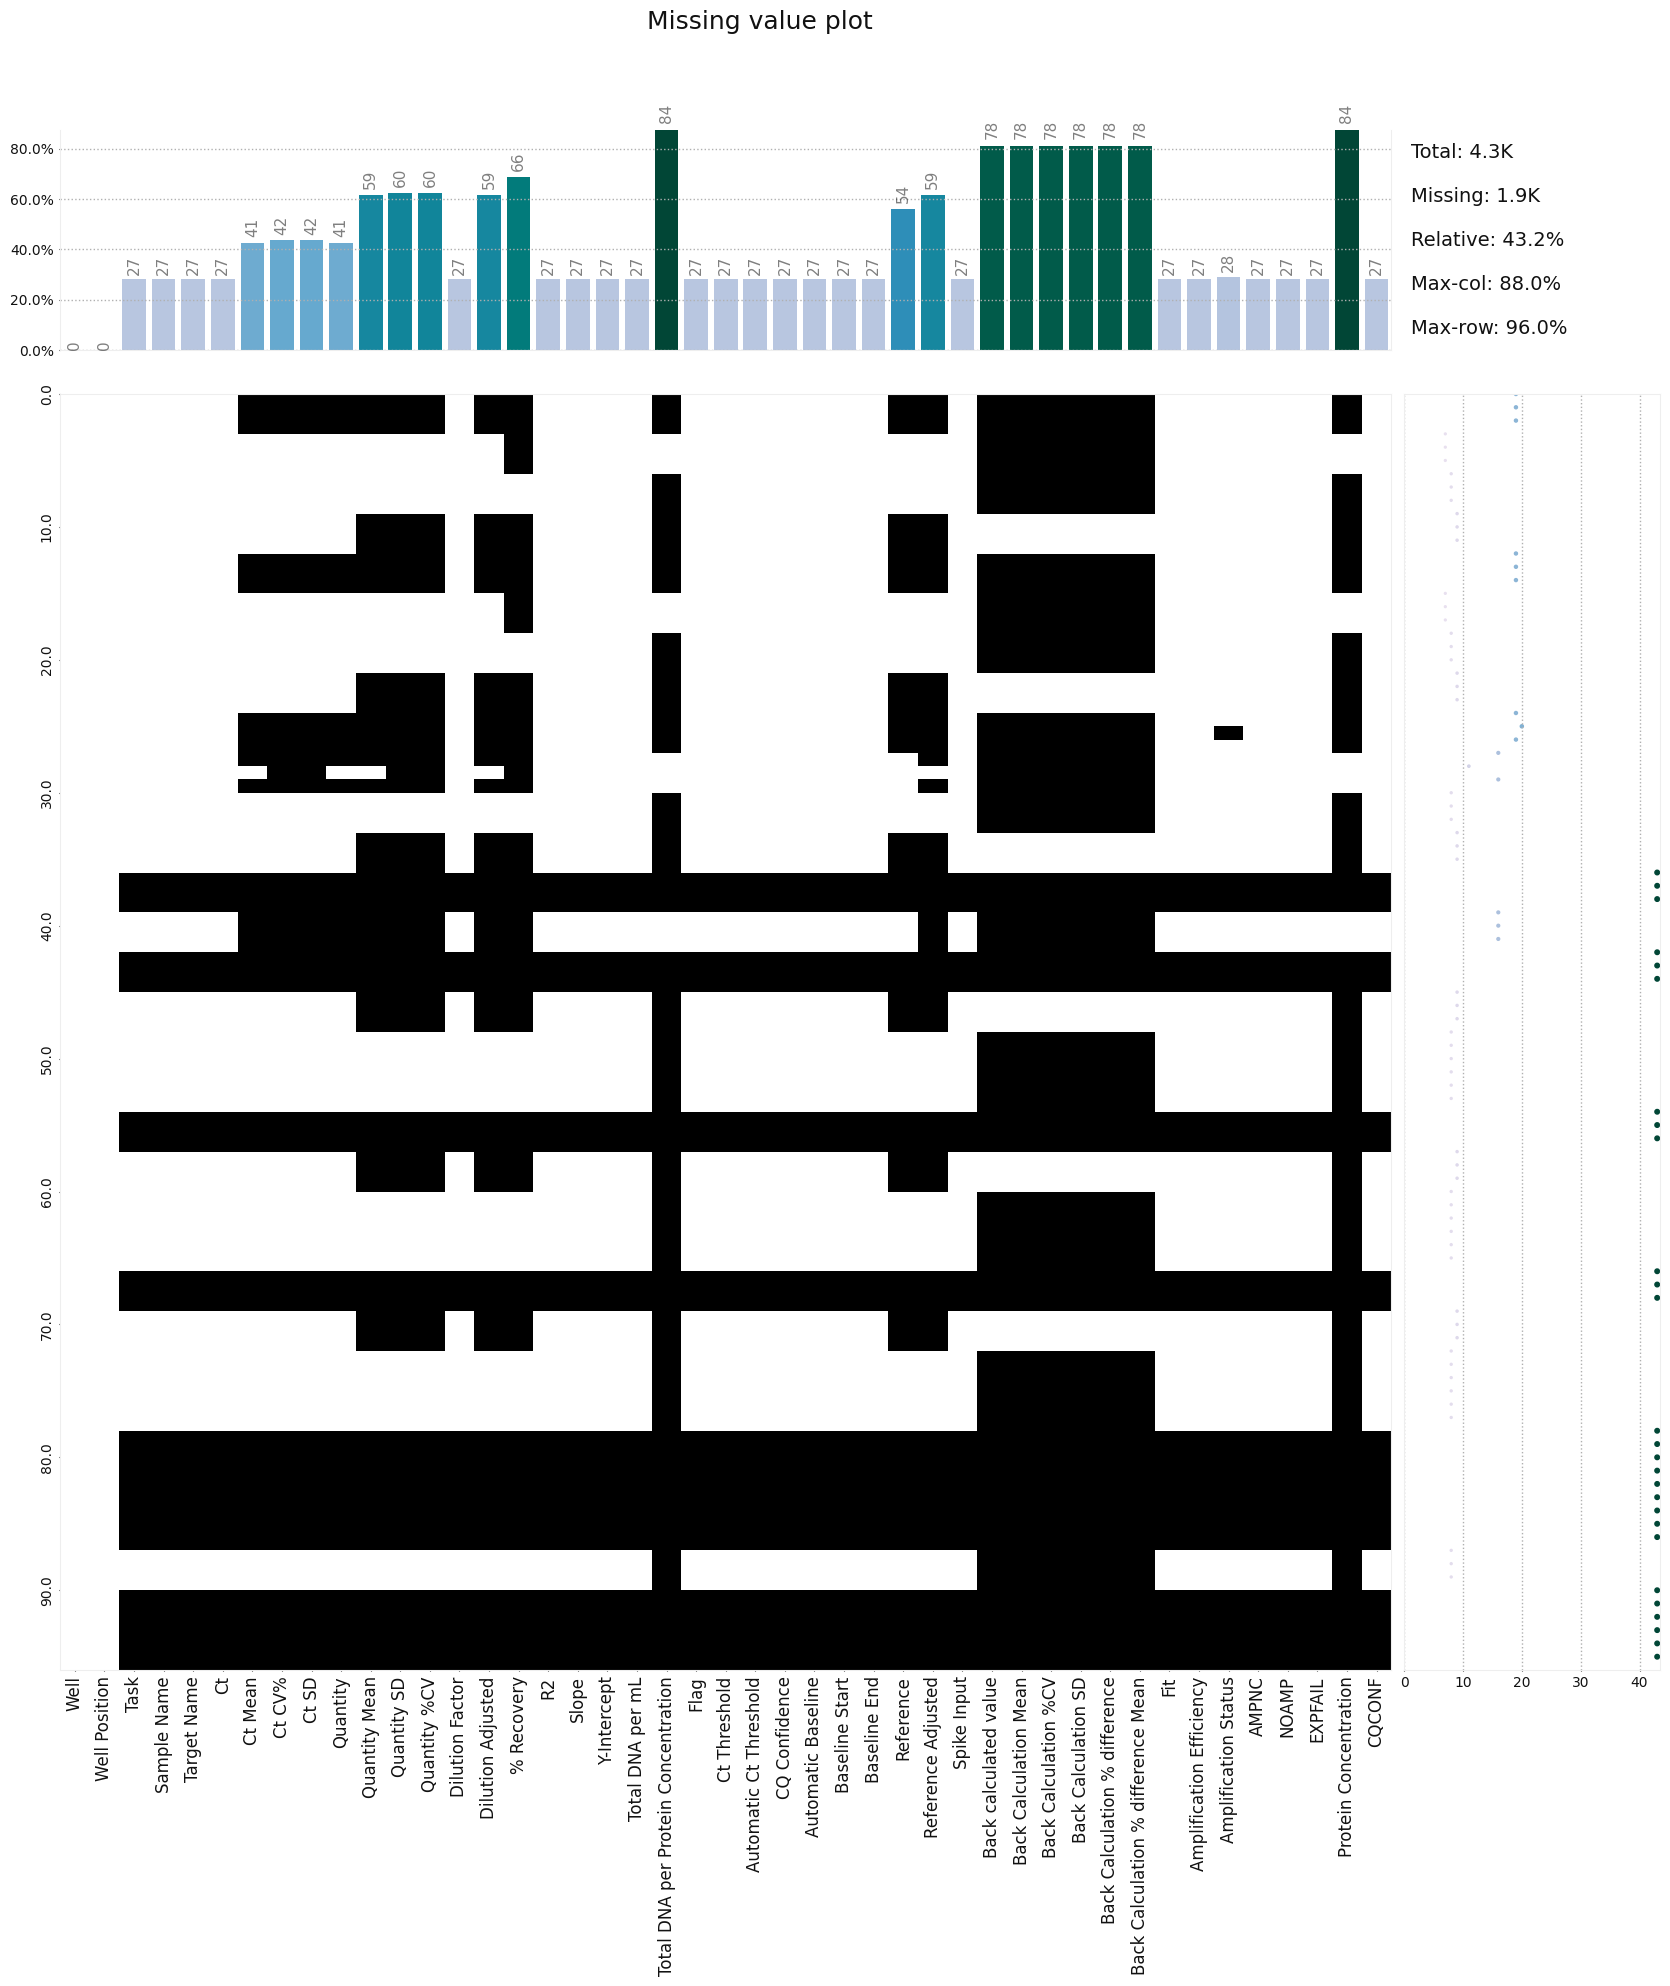

In [50]:
# Missing Value
klib.missingval_plot(df)

## QuantStudio Results Parser


```text
Results Parser
        │
        ├── Rename columns
        ├── Convert data types
        ├── Remove empty rows
        ├── Handle Undetermined Ct
        └── Produce standardized dataframe

```


### Rename or Standardize Columns

In [51]:
# Inspect attributes
print(df.columns.tolist())

['Well', 'Well Position', 'Task', 'Sample Name', 'Target Name', 'Ct', 'Ct Mean', 'Ct CV%', 'Ct SD', 'Quantity', 'Quantity Mean', 'Quantity SD', 'Quantity %CV', 'Dilution Factor', 'Dilution Adjusted', '% Recovery', 'R2', 'Slope', 'Y-Intercept', 'Total DNA per mL', 'Total DNA per Protein Concentration', 'Flag', 'Ct Threshold', 'Automatic Ct Threshold', 'CQ Confidence', 'Automatic Baseline', 'Baseline Start', 'Baseline End', 'Reference', 'Reference Adjusted', 'Spike Input', 'Back calculated value', 'Back Calculation Mean', 'Back Calculation %CV', 'Back Calculation SD', 'Back Calculation % difference', 'Back Calculation % difference Mean', 'Fit', 'Amplification Efficiency', 'Amplification Status', 'AMPNC', 'NOAMP', 'EXPFAIL', 'Protein Concentration', 'CQCONF']


In [52]:
# Standardize names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

print(df.columns.tolist())

['well', 'well_position', 'task', 'sample_name', 'target_name', 'ct', 'ct_mean', 'ct_cv%', 'ct_sd', 'quantity', 'quantity_mean', 'quantity_sd', 'quantity_%cv', 'dilution_factor', 'dilution_adjusted', '%_recovery', 'r2', 'slope', 'y_intercept', 'total_dna_per_ml', 'total_dna_per_protein_concentration', 'flag', 'ct_threshold', 'automatic_ct_threshold', 'cq_confidence', 'automatic_baseline', 'baseline_start', 'baseline_end', 'reference', 'reference_adjusted', 'spike_input', 'back_calculated_value', 'back_calculation_mean', 'back_calculation_%cv', 'back_calculation_sd', 'back_calculation_%_difference', 'back_calculation_%_difference_mean', 'fit', 'amplification_efficiency', 'amplification_status', 'ampnc', 'noamp', 'expfail', 'protein_concentration', 'cqconf']


### Convert Data Type

In [53]:
# Convert columns to numeric
numeric_columns = [
    "ct",
    "ct_mean",
    "ct_sd",
    "quantity",
    "quantity_mean",
    "quantity_sd"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [54]:
# verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   well                                 96 non-null     object 
 1   well_position                        96 non-null     int64  
 2   task                                 69 non-null     object 
 3   sample_name                          69 non-null     object 
 4   target_name                          69 non-null     object 
 5   ct                                   60 non-null     float64
 6   ct_mean                              55 non-null     float64
 7   ct_cv%                               54 non-null     float64
 8   ct_sd                                54 non-null     float64
 9   quantity                             55 non-null     float64
 10  quantity_mean                        37 non-null     float64
 11  quantity_sd                       

### Remove Empty Rows

In [55]:
# Clean the data or remove empty rows
# NOTE: klib.data_cleaning() drops single-valued columns, which silently removes
# r2/slope/y_intercept from df (they're single-valued because the demo dataset has
# exactly one qPCR target/curve for the whole plate). This is harmless today because
# the Standard Curve Statistics cell below reads its own copy of these values from
# regression_table (a separate, independent read of the Excel file) rather than from
# df — see that cell for details. If a future refactor pulls curve stats from df/
# samples_df instead, or if a plate ever has more than one target (so these columns
# stop being single-valued and klib stops dropping them), re-check that assumption.
df = klib.data_cleaning(df)

Shape of cleaned data: (69, 35) - Remaining NAs: 716


Dropped rows: 27
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 10
     of which 10 single valued.     Columns: ['target_name', 'r2', 'slope', 'y_intercept', 'ct_threshold', 'automatic_ct_threshold', 'automatic_baseline', 'baseline_start', 'fit', 'amplification_efficiency']
Dropped missing values: 1161
Reduced memory by at least: 0.02 MB (-66.67%)



### Transform Ct values into numeric ("Undetermined")

In [56]:
### Replace "Undetermined"
df["ct"] = (
    df["ct"]
      .replace("Undetermined", pd.NA)
)

df["ct"] = pd.to_numeric(df["ct"])

### Parser Summary

In [57]:
# Results Parser Summary
results_summary_table = pd.DataFrame([
    {"Field": "Rows", "Value": len(df)},
    {"Field": "Columns", "Value": len(df.columns)},
    {"Field": "Missing Ct values", "Value": df["ct"].isna().sum()},
    {"Field": "Unique Samples", "Value": df["sample_name"].nunique()},
    {"Field": "Unique Task", "Value": df["task"].nunique()},
])

style_table(results_summary_table, caption="Results Parser Summary", align="left")


Field,Value
Rows,69
Columns,35
Missing Ct values,9
Unique Samples,23
Unique Task,3


### Standardized Dataset - parsed_df

In [58]:
parsed_df = df.copy()
style_table(parsed_df.head(), caption="Standardized Dataset Preview")

well,well_position,task,sample_name,ct,ct_mean,ct_cv_percent,ct_sd,quantity,quantity_mean,quantity_sd,quantity_percent_cv,dilution_factor,dilution_adjusted,percent_recovery,total_dna_per_ml,total_dna_per_protein_concentration,flag,cq_confidence,baseline_end,reference,reference_adjusted,spike_input,back_calculated_value,back_calculation_mean,back_calculation_percent_cv,back_calculation_sd,back_calculation_percent_difference,back_calculation_percent_difference_mean,amplification_status,ampnc,noamp,expfail,protein_concentration,cqconf
A1,1,NTC,NTC,—,—,—,—,—,—,—,—,1.00,—,—,0.00,—,0.00,0.00,39.00,—,—,0.00,—,—,—,—,—,—,No Amp,N,N,N,—,N
A2,2,NTC,NTC,—,—,—,—,—,—,—,—,1.00,—,—,0.00,—,0.00,0.00,39.00,—,—,0.00,—,—,—,—,—,—,No Amp,N,N,N,—,N
A3,3,NTC,NTC,—,—,—,—,—,—,—,—,1.00,—,—,0.00,—,0.00,0.00,39.00,—,—,0.00,—,—,—,—,—,—,No Amp,N,N,N,—,N
A4,4,UNKNOWN,S1 D1,32.36,32.52,0.81,0.26,0.00,0.00,0.00,17.24,1.00,0.00,—,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,—,—,—,—,—,—,Amplification,N,N,N,1.83,N
A5,5,UNKNOWN,S1 D1,32.37,32.52,0.81,0.26,0.00,0.00,0.00,17.24,1.00,0.00,—,0.00,0.00,0.00,1.00,28.00,0.00,0.00,0.00,—,—,—,—,—,—,Amplification,N,N,N,1.83,N


### Output Verification — Instrument Pass-Through Integrity

In [ ]:
# Instrument-computed QC values (Ct CV%, Quantity %CV, % Recovery, Back Calculation
# % difference Mean) are read forward as-is rather than recalculated — see README
# Acceptance Criteria. This re-reads the untouched Results sheet and checks, well by
# well, that renaming/klib cleaning didn't drop or misalign any of them. It does NOT
# validate the instrument's own math, only that the parser preserved it correctly.
_raw_check_df = pd.read_excel(file, sheet_name="Results", header=22, engine=EXCEL_ENGINE)

_passthrough_columns = {
    "Ct CV%": "ct_cv_percent",
    "Quantity %CV": "quantity_percent_cv",
    "% Recovery": "percent_recovery",
    "Back Calculation % difference Mean": "back_calculation_percent_difference_mean",
}

_check_rows = []
for raw_col, parsed_col in _passthrough_columns.items():
    if raw_col not in _raw_check_df.columns or parsed_col not in parsed_df.columns:
        _check_rows.append({
            "Column": raw_col,
            "Wells Checked": 0,
            "Mismatches": "—",
            "Status": "Missing",
        })
        continue

    merged = parsed_df[["well", parsed_col]].merge(
        _raw_check_df[["Well", raw_col]].rename(columns={"Well": "well"}),
        on="well",
        how="left",
    )
    checked = merged.dropna(subset=[parsed_col, raw_col])
    mismatches = checked[
        ~np.isclose(checked[parsed_col].astype(float), checked[raw_col].astype(float))
    ]

    _check_rows.append({
        "Column": raw_col,
        "Wells Checked": len(checked),
        "Mismatches": len(mismatches),
        "Status": "Pass" if mismatches.empty else "Fail",
    })

passthrough_check_table = pd.DataFrame(_check_rows)

style_table(
    passthrough_check_table,
    caption="Output Verification — Instrument Pass-Through Integrity",
    align="left",
    highlight_rows=passthrough_check_table["Status"] == "Fail",
    highlight_color="#F8D7DA",
)


## Data Classification Engine

```text
Classification Engine
        │
        ├── Reference Standard   (STD curve points)
        ├── Controls
        │     ├── NTC   No Template Control
        │     ├── NEC   No Extraction Control
        │     ├── ERC   Extraction Recovery Control
        │     └── PC    Positive Control (HPC / MPC / LPC)
        └── Sample(s)             (unknowns)

```

### Classify Task / Sample Name

In [60]:
# Classify each well into Reference Standard, Control, or Sample
def classify_sample(sample_name, task):
    name = str(sample_name).strip().upper()

    if task == "STANDARD" or name.startswith("STD"):
        return pd.Series(["Reference Standard", "STD"])
    if name.startswith("NTC"):
        return pd.Series(["Control", "NTC"])
    if name.startswith("NEC"):
        return pd.Series(["Control", "NEC"])
    if name.startswith("ERC"):
        return pd.Series(["Control", "ERC"])
    if name.startswith("HPC"):
        return pd.Series(["Control", "HPC"])
    if name.startswith("MPC"):
        return pd.Series(["Control", "MPC"])
    if name.startswith("LPC"):
        return pd.Series(["Control", "LPC"])
    return pd.Series(["Sample", "Sample"])

parsed_df[["sample_group", "control_type"]] = parsed_df.apply(
    lambda row: classify_sample(row["sample_name"], row["task"]),
    axis=1
)

classification_table = (
    parsed_df[["sample_name", "task", "sample_group", "control_type"]]
    .drop_duplicates()
    .sort_values(["sample_group", "control_type", "sample_name"])
    .reset_index(drop=True)
)

style_table(classification_table, caption="Sample Classification", align="left")

sample_name,task,sample_group,control_type
ERC - 10,UNKNOWN,Control,ERC
ERC - 30,UNKNOWN,Control,ERC
ERC - 60,UNKNOWN,Control,ERC
HPC - 190,UNKNOWN,Control,HPC
LPC - 5,UNKNOWN,Control,LPC
MPC - 10,UNKNOWN,Control,MPC
NEC - FB,NTC,Control,NEC
NEC - PBS,NTC,Control,NEC
NTC,NTC,Control,NTC
STD 0.003,STANDARD,Reference Standard,STD


### Split by Group

In [61]:
# Split the standardized dataset into its three groups
ref_std_df = parsed_df[parsed_df["sample_group"] == "Reference Standard"].copy()
controls_df = parsed_df[parsed_df["sample_group"] == "Control"].copy()
samples_df = parsed_df[parsed_df["sample_group"] == "Sample"].copy()

# Group dilutions under their base sample, e.g. "S1 D1", "S1 D2" -> "S1"
# (strips an optional legacy " S" spike suffix too, so any leftover spiked rows still map correctly)
samples_df["base_sample"] = samples_df["sample_name"].str.replace(r"\s+D\d+(?:\s+S)?$", "", regex=True)

### Classification Summary

In [62]:
# Summarize each group as a presentable table
summary_table = (
    parsed_df
    .groupby(["sample_group", "control_type"], as_index=False)
    .agg(**{
        "Unique Samples": ("sample_name", "nunique"),
        "Rows": ("sample_name", "size"),
    })
    .rename(columns={"sample_group": "Group", "control_type": "Subtype"})
)

total_row = pd.DataFrame([{
    "Group": "Total",
    "Subtype": "",
    "Unique Samples": parsed_df["sample_name"].nunique(),
    "Rows": len(parsed_df),
}])

summary_table = pd.concat([summary_table, total_row], ignore_index=True)

style_table(summary_table, caption="Data Classification Summary", precision=0, align="left")

Group,Subtype,Unique Samples,Rows
Control,ERC,3,9
Control,HPC,1,3
Control,LPC,1,3
Control,MPC,1,3
Control,NEC,2,6
Control,NTC,1,3
Reference Standard,STD,6,18
Sample,Sample,8,24
Total,,23,69


## Acceptance Criteria

All System Suitability and Sample Suitability thresholds, in one place — the natural seam for the Phase III criteria-settings page. Editable as Colab form fields; outside Colab they're just regular constants with these defaults.

In [63]:
#@markdown ## STD Curve
STD_R2_MIN = 0.99 #@param {type:"number"}
STD_CT_CV_MAX = 20.0 #@param {type:"number"}
STD_BACK_CALC_BIAS_MAX = 25.0 #@param {type:"number"}
STD_EFFICIENCY_MIN = 90.0 #@param {type:"number"}
STD_EFFICIENCY_MAX = 110.0 #@param {type:"number"}

#@markdown ## ERC / PC Controls
CTRL_QTY_CV_MAX = 20.0 #@param {type:"number"}
PC_RECOVERY_MIN = 80.0 #@param {type:"number"}
PC_RECOVERY_MAX = 125.0 #@param {type:"number"}
ERC_RECOVERY_MIN = 50.0 #@param {type:"number"}
ERC_RECOVERY_MAX = 150.0 #@param {type:"number"}

#@markdown ## LOD / LOQ — ICH Q2(R1) / USP <1225>
#@markdown sigma = residual standard deviation of the regression line ("Std error")
LOD_SIGMA_MULTIPLIER = 3.3 #@param {type:"number"}
LOQ_SIGMA_MULTIPLIER = 10.0 #@param {type:"number"}

#@markdown ## Sample Suitability
SAMPLE_QTY_CV_MAX = 25.0 #@param {type:"number"}
SAMPLE_LINEARITY_BIAS_MAX = 20 #@param {type:"number"}
#@markdown Reportable DNA per Protein limit, in ng/mg
SAMPLE_DNA_PER_PROTEIN_LIMIT = 15.0 #@param {type:"number"}

## System Suitability Engine

```text
System Suitability Engine
        │
        ├── STD Curve      R² ≥ 0.99, Efficiency 90-110%,
        │                 Ct %CV ≤ 20%, Back-Calc %Bias ≤ 25%
        ├── ERC / PC       Quantity %CV ≤ 20%, %Recovery in range
        └── NTC / NEC      Undetermined, or Ct ≥ LOQ Ct

```

### Standard Curve Statistics

In [64]:
# Pull the curve statistics already captured in regression_table
# NOTE: regression_table (built above from a fixed row/column range in the raw Excel
# sheet) is the *only* source for curve stats used here — r2/slope/y_intercept were
# dropped from df by klib.data_cleaning() (see that cell's note). This assumes one
# qPCR target/curve per plate; a multi-target plate would need per-target curve stats
# instead of this single fixed-offset read.
reg_stats = regression_table.set_index("Metric")["Value"].astype(float)

curve_r2 = reg_stats["R2"]
curve_slope = reg_stats["Slope"]
curve_intercept = reg_stats["y-Intercept"]
curve_efficiency = reg_stats["Efficiency"]
curve_std_error = reg_stats["Std error"]

# Convert the sigma/slope offset (log10 quantity) back into Ct space via the curve equation
lod_log_qty = LOD_SIGMA_MULTIPLIER * curve_std_error / abs(curve_slope)
loq_log_qty = LOQ_SIGMA_MULTIPLIER * curve_std_error / abs(curve_slope)

lod_ct = curve_slope * lod_log_qty + curve_intercept
loq_ct = curve_slope * loq_log_qty + curve_intercept

print(f"R²={curve_r2}  Slope={curve_slope}  Intercept={curve_intercept}  "
      f"Efficiency={curve_efficiency}%  Std Error={curve_std_error}")
print(f"LOD Ct = {lod_ct:.4f}   LOQ Ct = {loq_ct:.4f}")

R²=0.9998  Slope=-3.3008  Intercept=21.3153  Efficiency=100.89%  Std Error=0.0116
LOD Ct = 21.2770   LOQ Ct = 21.1993


### STD Curve Suitability

In [65]:
curve_checks = pd.DataFrame([
    {
        "Check": "R² ≥ 0.99",
        "Value": curve_r2,
        "Pass": curve_r2 >= STD_R2_MIN,
    },
    {
        "Check": "Amplification Efficiency 90-110%",
        "Value": curve_efficiency,
        "Pass": STD_EFFICIENCY_MIN <= curve_efficiency <= STD_EFFICIENCY_MAX,
    },
])

style_table(curve_checks, caption="Standard Curve Suitability", align="left")

Check,Value,Pass
R² ≥ 0.99,1.00,True
Amplification Efficiency 90-110%,100.89,True


### STD Curve Point Suitability

In [66]:
std_suitability = (
    ref_std_df
    .groupby("sample_name", as_index=False)
    .agg(**{
        "Quantity": ("quantity", "first"),
        "Ct %CV": ("ct_cv_percent", "first"),
        "Back-Calc %Bias": ("back_calculation_percent_difference_mean", "first"),
    })
    .sort_values("Quantity")
    .reset_index(drop=True)
)

std_suitability["Ct %CV Pass"] = std_suitability["Ct %CV"] <= STD_CT_CV_MAX
std_suitability["Back-Calc Pass"] = std_suitability["Back-Calc %Bias"].abs() <= STD_BACK_CALC_BIAS_MAX

style_table(
    std_suitability.rename(columns={"sample_name": "Sample"}),
    caption="Standard Curve Point Suitability",
    align="left",
)

Sample,Quantity,Ct %CV,Back-Calc %Bias,Ct %CV Pass,Back-Calc Pass
STD 0.003,0.00,0.47,5.06,True,True
STD 0.03,0.03,0.11,-4.04,True,True
STD 0.3,0.30,0.29,-1.75,True,True
STD 3,3.00,0.34,-2.85,True,True
STD 30,30.00,0.19,-1.25,True,True
STD 300,300.00,0.46,3.93,True,True


### ERC & PC Suitability

In [67]:
control_suitability = (
    controls_df[controls_df["control_type"].isin(["ERC", "HPC", "MPC", "LPC"])]
    .groupby(["control_type", "sample_name"], as_index=False)
    .agg(**{
        "Quantity %CV": ("quantity_percent_cv", "first"),
        "% Recovery": ("percent_recovery", "first"),
    })
)

def recovery_bounds(control_type):
    if control_type in ("HPC", "MPC", "LPC"):
        return PC_RECOVERY_MIN, PC_RECOVERY_MAX
    return ERC_RECOVERY_MIN, ERC_RECOVERY_MAX

control_suitability["CV Pass"] = control_suitability["Quantity %CV"] <= CTRL_QTY_CV_MAX
control_suitability["Recovery Pass"] = control_suitability.apply(
    lambda row: recovery_bounds(row["control_type"])[0]
    <= row["% Recovery"]
    <= recovery_bounds(row["control_type"])[1],
    axis=1,
)

style_table(
    control_suitability.rename(columns={"control_type": "Control Type", "sample_name": "Sample"}),
    caption="ERC & PC Suitability",
    align="left",
)

Control Type,Sample,Quantity %CV,% Recovery,CV Pass,Recovery Pass
ERC,ERC - 10,1.12,68.58,True,True
ERC,ERC - 30,1.91,66.91,True,True
ERC,ERC - 60,3.06,70.84,True,True
HPC,HPC - 190,10.26,112.88,True,True
LPC,LPC - 5,0.70,109.67,True,True
MPC,MPC - 10,5.17,109.87,True,True


### NTC & NEC Suitability

In [68]:
# Both NTC and NEC pass per well if Ct is undetermined, or at/below the assay's
# quantifiable sensitivity (i.e. Ct at or later than the LOQ Ct — lower concentration
# than the LOQ)
negative_controls_df = controls_df[controls_df["control_type"].isin(["NTC", "NEC"])].copy()
negative_controls_df["well_pass"] = negative_controls_df["ct"].isna() | (negative_controls_df["ct"] >= loq_ct)

negative_control_summary = (
    negative_controls_df.groupby(["control_type", "sample_name"], as_index=False)
    .agg(**{"Wells Passing": ("well_pass", "sum"), "Total Wells": ("well_pass", "size")})
)
negative_control_summary["Pass"] = (
    negative_control_summary["Wells Passing"] == negative_control_summary["Total Wells"]
)
negative_control_summary = negative_control_summary.rename(
    columns={"control_type": "Control Type", "sample_name": "Sample"}
)

ntc_pass = bool(
    negative_control_summary.loc[negative_control_summary["Control Type"] == "NTC", "Pass"].all()
)
nec_summary = negative_control_summary[negative_control_summary["Control Type"] == "NEC"]

style_table(
    negative_control_summary,
    caption=f"Negative Control Suitability (LOQ Ct = {loq_ct:.2f})",
    align="left",
    precision=0,
)


Control Type,Sample,Wells Passing,Total Wells,Pass
NEC,NEC - FB,3,3,True
NEC,NEC - PBS,3,3,True
NTC,NTC,3,3,True


## System Suitability Summary

In [69]:
system_suitability_pass = bool(
    (curve_r2 >= STD_R2_MIN)
    and (STD_EFFICIENCY_MIN <= curve_efficiency <= STD_EFFICIENCY_MAX)
    and std_suitability["Ct %CV Pass"].all()
    and std_suitability["Back-Calc Pass"].all()
    and control_suitability["CV Pass"].all()
    and control_suitability["Recovery Pass"].all()
    and ntc_pass
    and nec_summary["Pass"].all()
)

status = "PASS" if system_suitability_pass else "FAIL"

from IPython.display import display, HTML

_banner_bg = "#D4EDDA" if system_suitability_pass else "#F8D7DA"
_banner_accent = "#28A745" if system_suitability_pass else "#DC3545"
_banner_text = "#155724" if system_suitability_pass else "#721C24"

display(HTML(f"""
<div style="
    background-color:{_banner_bg};
    border-left: 6px solid {_banner_accent};
    color:{_banner_text};
    padding: 14px 22px;
    margin: 12px 0;
    font-size: 16pt;
    font-weight: bold;
    font-family: -apple-system, 'Segoe UI', sans-serif;
    border-radius: 4px;
    letter-spacing: 0.5px;
">
    System Suitability: {status}
</div>
"""))

# STD Curve Fit — one row (Curve Fit is plate-level, not per-item), both checks as
# their own Value/Pass columns
curve_fit_wide = pd.DataFrame([{
    "Item": "Curve Fit",
    "R²": f"{curve_r2:.2f}",
    "R² Pass": "Pass" if curve_r2 >= STD_R2_MIN else "Fail",
    "Efficiency %": f"{curve_efficiency:.2f}",
    "Efficiency Pass": "Pass" if STD_EFFICIENCY_MIN <= curve_efficiency <= STD_EFFICIENCY_MAX else "Fail",
}])
display_wide_table(
    curve_fit_wide,
    caption="System Suitability — STD Curve Fit",
    fail_mask=(curve_fit_wide["R² Pass"] == "Fail") | (curve_fit_wide["Efficiency Pass"] == "Fail"),
)

# STD Curve Points — one row per point, Ct %CV and Back-Calc %Bias side by side
std_points_wide = std_suitability.rename(columns={"sample_name": "Item"})[[
    "Item", "Ct %CV", "Ct %CV Pass", "Back-Calc %Bias", "Back-Calc Pass"
]].copy()
std_points_wide["Ct %CV Pass"] = std_points_wide["Ct %CV Pass"].map({True: "Pass", False: "Fail"})
std_points_wide["Back-Calc Pass"] = std_points_wide["Back-Calc Pass"].map({True: "Pass", False: "Fail"})
display_wide_table(
    std_points_wide,
    caption="System Suitability — STD Curve Points",
    fail_mask=(std_points_wide["Ct %CV Pass"] == "Fail") | (std_points_wide["Back-Calc Pass"] == "Fail"),
)

# ERC / PC — one row per control, Quantity %CV and % Recovery side by side
erc_pc_wide = control_suitability.copy()
erc_pc_wide["Item"] = erc_pc_wide["sample_name"] + " (" + erc_pc_wide["control_type"] + ")"
erc_pc_wide["CV Pass"] = erc_pc_wide["CV Pass"].map({True: "Pass", False: "Fail"})
erc_pc_wide["Recovery Pass"] = erc_pc_wide["Recovery Pass"].map({True: "Pass", False: "Fail"})
erc_pc_wide = erc_pc_wide[["Item", "Quantity %CV", "CV Pass", "% Recovery", "Recovery Pass"]]
display_wide_table(
    erc_pc_wide,
    caption="System Suitability — ERC / PC",
    fail_mask=(erc_pc_wide["CV Pass"] == "Fail") | (erc_pc_wide["Recovery Pass"] == "Fail"),
)

# NTC / NEC — already one row per item with a single criterion, so long and wide
# format are the same here
ntc_nec_rows = []

for _, row in negative_control_summary.iterrows():
    ntc_nec_rows.append({
        "Item": f"{row['Sample']} ({row['Control Type']})",
        "Criteria": "Undetermined, or Ct ≥ LOQ Ct",
        "Value": f"{row['Wells Passing']}/{row['Total Wells']}",
        "Status": "Pass" if row["Pass"] else "Fail",
    })

display_criteria_group(ntc_nec_rows, caption="System Suitability — NTC / NEC")

Item,R²,R² Pass,Efficiency %,Efficiency Pass
Curve Fit,1.00,Pass,100.89,Pass


Item,Ct %CV,Ct %CV Pass,Back-Calc %Bias,Back-Calc Pass
STD 0.003,0.47,Pass,5.06,Pass
STD 0.03,0.11,Pass,-4.04,Pass
STD 0.3,0.29,Pass,-1.75,Pass
STD 3,0.34,Pass,-2.85,Pass
STD 30,0.19,Pass,-1.25,Pass
STD 300,0.46,Pass,3.93,Pass


Item,Quantity %CV,CV Pass,% Recovery,Recovery Pass
ERC - 10 (ERC),1.12,Pass,68.58,Pass
ERC - 30 (ERC),1.91,Pass,66.91,Pass
ERC - 60 (ERC),3.06,Pass,70.84,Pass
HPC - 190 (HPC),10.26,Pass,112.88,Pass
LPC - 5 (LPC),0.70,Pass,109.67,Pass
MPC - 10 (MPC),5.17,Pass,109.87,Pass


Item,Criteria,Value,Status
NEC - FB (NEC),"Undetermined, or Ct ≥ LOQ Ct",3/3,Pass
NEC - PBS (NEC),"Undetermined, or Ct ≥ LOQ Ct",3/3,Pass
NTC (NTC),"Undetermined, or Ct ≥ LOQ Ct",3/3,Pass


## Sample Result Processing

```text
Sample Suitability Checks
        │
        ├── Quantity %CV          triplicate %CV ≤ 25%
        └── Dilutional Linearity  %Bias vs. each sample's lowest-CV reference dilution ≤ 20%

```

### Sample %CV Suitability

In [70]:
sample_cv = (
    samples_df
    .groupby("sample_name", as_index=False)
    .agg(**{"Quantity %CV": ("quantity_percent_cv", "first")})
    .sort_values("sample_name")
    .reset_index(drop=True)
)

sample_cv["Pass"] = (sample_cv["Quantity %CV"] <= SAMPLE_QTY_CV_MAX).astype(object)
# Below-LOQ / non-amplifying replicates have no %CV to evaluate — mark as N/A rather than fail
sample_cv.loc[sample_cv["Quantity %CV"].isna(), "Pass"] = pd.NA

style_table(
    sample_cv.rename(columns={"sample_name": "Sample"}),
    caption="Sample %CV Suitability (Triplicate Quantity)",
    align="left",
)

Sample,Quantity %CV,Pass
S1 D1,17.24,True
S1 D1 S,2.90,True
S1 D2,21.52,True
S1 D2 S,2.69,True
S1 D3,—,—
S1 D3 S,1.67,True
S1 D4,—,—
S1 D4 S,2.97,True


### Dilutional Linearity Suitability

In [71]:
# Reference-dilution approach: for each sample, the dilution with the lowest combined
# Ct %CV + Quantity %CV (its most precise triplicate) is taken as the reference. Every
# dilution's Dilution Adjusted quantity is then compared to that reference to test
# linearity across the series — this replaces the old spike-based %Recovery check, since
# spiked series are no longer collected.
unspiked_dilutions = (
    samples_df[~samples_df["sample_name"].str.endswith(" S")]
    .drop_duplicates(subset="sample_name")
    [["base_sample", "sample_name", "ct_cv_percent", "quantity_percent_cv", "dilution_adjusted"]]
    .copy()
)

_combined_cv = (
    unspiked_dilutions["ct_cv_percent"].fillna(float("inf"))
    + unspiked_dilutions["quantity_percent_cv"].fillna(float("inf"))
)

reference_dilution_adjusted = (
    unspiked_dilutions.assign(combined_cv=_combined_cv)
    .sort_values("combined_cv")
    .drop_duplicates(subset="base_sample", keep="first")
    .set_index("base_sample")["dilution_adjusted"]
)

linearity_df = unspiked_dilutions.copy()
linearity_df["Reference Dilution Adjusted"] = linearity_df["base_sample"].map(reference_dilution_adjusted)

# % Bias = (x1 - x2) / x2 × 100, where x2 is the sample's reference dilution
linearity_df["% Bias"] = (
    (linearity_df["dilution_adjusted"] - linearity_df["Reference Dilution Adjusted"])
    / linearity_df["Reference Dilution Adjusted"] * 100
)
linearity_df["Pass"] = (linearity_df["% Bias"].abs() <= SAMPLE_LINEARITY_BIAS_MAX).astype(object)
linearity_df.loc[linearity_df["% Bias"].isna(), "Pass"] = pd.NA

linearity_df = linearity_df.rename(columns={
    "base_sample": "Base Sample",
    "sample_name": "Sample",
    "dilution_adjusted": "Dilution Adjusted",
})[["Base Sample", "Sample", "Dilution Adjusted", "Reference Dilution Adjusted", "% Bias", "Pass"]]

style_table(
    linearity_df,
    caption="Dilutional Linearity Suitability (vs. each sample's lowest-CV reference dilution)",
    align="left",
    precision_overrides={"Dilution Adjusted": 4, "Reference Dilution Adjusted": 4},
)

Base Sample,Sample,Dilution Adjusted,Reference Dilution Adjusted,% Bias,Pass
S1,S1 D1,0.0004,0.0004,0.00,True
S1,S1 D2,0.0004,0.0004,0.00,True
S1,S1 D3,—,0.0004,—,—
S1,S1 D4,—,0.0004,—,—


### Manual Golden-Reference Check — Dilutional Linearity % Bias

In [72]:
# % Bias above is the one suitability value actually computed in this notebook rather
# than pulled from the instrument (see README Acceptance Criteria). Hand-calculate (or
# Excel-calculate) the expected % Bias for a few known dilutions against the
# reference-dilution formula, fill them in below, and re-run this cell — this is a
# one-time golden-reference check, not something to compute automatically.
GOLDEN_LINEARITY_BIAS = {
    # "S1 D2": 3.42,
}

GOLDEN_BIAS_TOLERANCE = 0.01  # absolute %-point tolerance for floating-point rounding

golden_check_rows = []
for sample, expected_bias in GOLDEN_LINEARITY_BIAS.items():
    actual_row = linearity_df.loc[linearity_df["Sample"] == sample]
    if actual_row.empty:
        golden_check_rows.append({
            "Sample": sample,
            "Expected % Bias": expected_bias,
            "Notebook % Bias": None,
            "Status": "Not Found",
        })
        continue

    actual_bias = actual_row["% Bias"].iloc[0]
    match = pd.notna(actual_bias) and abs(actual_bias - expected_bias) <= GOLDEN_BIAS_TOLERANCE
    golden_check_rows.append({
        "Sample": sample,
        "Expected % Bias": expected_bias,
        "Notebook % Bias": actual_bias,
        "Status": "Pass" if match else "Fail",
    })

if golden_check_rows:
    golden_check_table = pd.DataFrame(golden_check_rows)
    style_table(
        golden_check_table,
        caption="Manual Golden-Reference Check — Dilutional Linearity % Bias",
        align="left",
        highlight_rows=golden_check_table["Status"] != "Pass",
        highlight_color="#F8D7DA",
    )
else:
    print("No golden-reference values entered yet — fill in GOLDEN_LINEARITY_BIAS above.")


No golden-reference values entered yet — fill in GOLDEN_LINEARITY_BIAS above.


## Sample Suitability Summary

In [ ]:
# Consolidate every criterion evaluated above (Quantity %CV, Dilutional Linearity),
# one table per group rather than one long combined table
quantity_cv_rows = []

for _, row in sample_cv.iterrows():
    if pd.isna(row["Pass"]):
        row_status = "N/A"
    else:
        row_status = "Pass" if row["Pass"] else "Fail"
    quantity_cv_rows.append({
        "Item": row["sample_name"],
        "Criteria": f"Triplicate %CV ≤ {SAMPLE_QTY_CV_MAX:g}",
        "Value": "—" if pd.isna(row["Quantity %CV"]) else f"{row['Quantity %CV']:.2f}",
        "Status": row_status,
    })

linearity_rows = []

for _, row in linearity_df.iterrows():
    if pd.isna(row["Pass"]):
        row_status = "N/A"
    else:
        row_status = "Pass" if row["Pass"] else "Fail"
    linearity_rows.append({
        "Item": row["Sample"],
        "Criteria": f"%Bias vs. reference dilution ≤ {SAMPLE_LINEARITY_BIAS_MAX:g}",
        "Value": "—" if pd.isna(row["% Bias"]) else f"{row['% Bias']:.2f}",
        "Status": row_status,
    })

display_criteria_group(quantity_cv_rows, caption="Sample Suitability — Quantity %CV")
display_criteria_group(linearity_rows, caption="Sample Suitability — Dilutional Linearity")

## Final Sample Results

#### Sample Name Mapping

Detected Base Samples for this run print just below — up to 8 samples are supported per run (as few as 1). For each one, fill in its **Sample ID** and **Sample Name** in the boxes below; leave a row's **Base Sample** box blank if that slot isn't used this run. `Sample ID` and `Sample Name` left blank stay blank. Rows whose `Base Sample` doesn't match a detected sample are ignored (with a warning) rather than silently applied.


In [74]:
# Detect every Base Sample present in this run (e.g. "S1", "S2", ...) so you know
# which values to type into the Base Sample boxes below.
_base_sample_ids = sorted(
    samples_df["sample_name"].str.replace(r"\s+D\d+(?:\s+S)?$", "", regex=True).unique()
)
print(f"Detected Base Samples in this run: {_base_sample_ids}")

#@markdown Type each detected Base Sample above into a row below, along with its
#@markdown Sample ID and Sample Name. Leave a row's Base Sample blank if unused —
#@markdown up to 8 samples per run are supported.

#@markdown ## Sample 1
SAMPLE_1_BASE = "" #@param {type:"string"}
SAMPLE_1_ID = "" #@param {type:"string"}
SAMPLE_1_NAME = "" #@param {type:"string"}

#@markdown ## Sample 2
SAMPLE_2_BASE = "" #@param {type:"string"}
SAMPLE_2_ID = "" #@param {type:"string"}
SAMPLE_2_NAME = "" #@param {type:"string"}

#@markdown ## Sample 3
SAMPLE_3_BASE = "" #@param {type:"string"}
SAMPLE_3_ID = "" #@param {type:"string"}
SAMPLE_3_NAME = "" #@param {type:"string"}

#@markdown ## Sample 4
SAMPLE_4_BASE = "" #@param {type:"string"}
SAMPLE_4_ID = "" #@param {type:"string"}
SAMPLE_4_NAME = "" #@param {type:"string"}

#@markdown ## Sample 5
SAMPLE_5_BASE = "" #@param {type:"string"}
SAMPLE_5_ID = "" #@param {type:"string"}
SAMPLE_5_NAME = "" #@param {type:"string"}

#@markdown ## Sample 6
SAMPLE_6_BASE = "" #@param {type:"string"}
SAMPLE_6_ID = "" #@param {type:"string"}
SAMPLE_6_NAME = "" #@param {type:"string"}

#@markdown ## Sample 7
SAMPLE_7_BASE = "" #@param {type:"string"}
SAMPLE_7_ID = "" #@param {type:"string"}
SAMPLE_7_NAME = "" #@param {type:"string"}

#@markdown ## Sample 8
SAMPLE_8_BASE = "" #@param {type:"string"}
SAMPLE_8_ID = "" #@param {type:"string"}
SAMPLE_8_NAME = "" #@param {type:"string"}

_sample_mapping_rows = [
    (SAMPLE_1_BASE, SAMPLE_1_ID, SAMPLE_1_NAME),
    (SAMPLE_2_BASE, SAMPLE_2_ID, SAMPLE_2_NAME),
    (SAMPLE_3_BASE, SAMPLE_3_ID, SAMPLE_3_NAME),
    (SAMPLE_4_BASE, SAMPLE_4_ID, SAMPLE_4_NAME),
    (SAMPLE_5_BASE, SAMPLE_5_ID, SAMPLE_5_NAME),
    (SAMPLE_6_BASE, SAMPLE_6_ID, SAMPLE_6_NAME),
    (SAMPLE_7_BASE, SAMPLE_7_ID, SAMPLE_7_NAME),
    (SAMPLE_8_BASE, SAMPLE_8_ID, SAMPLE_8_NAME),
]

# Every Base Sample actually detected in this run, defaulting to a blank Sample ID /
# Sample Name until filled in via the boxes above
sample_id_map = {sample_id: "" for sample_id in _base_sample_ids}
sample_display_names = {sample_id: "" for sample_id in _base_sample_ids}

for _base, _sid, _name in _sample_mapping_rows:
    _base = _base.strip()
    if not _base:
        continue
    if _base not in sample_display_names:
        print(f"Sample mapping: '{_base}' does not match any detected Base Sample "
              f"{_base_sample_ids} — ignoring this row.")
        continue
    sample_id_map[_base] = _sid.strip()
    sample_display_names[_base] = _name.strip()


Detected Base Samples in this run: ['S1']


In [ ]:
# Report every unspiked dilution for every sample, then average each sample's
# suitability-passing dilutions (Quantity %CV AND Dilutional Linearity) into a single
# Total DNA / DNA per Protein result. SAMPLE_DNA_PER_PROTEIN_LIMIT is defined in
# the Acceptance Criteria section above.
unspiked_samples = samples_df[~samples_df["sample_name"].str.endswith(" S")].copy()

final_results = (
    unspiked_samples
    .drop_duplicates(subset="sample_name")
    [[
        "base_sample",
        "sample_name",
        "dilution_factor",
        "quantity_percent_cv",
        "total_dna_per_ml",
        "protein_concentration",
        "total_dna_per_protein_concentration",
    ]]
    .rename(columns={
        "base_sample": "Base Sample",
        "sample_name": "Sample",
        "dilution_factor": "Dilution Factor",
        "quantity_percent_cv": "Quantity %CV",
        "total_dna_per_ml": "Total DNA (ng/mL)",
        "protein_concentration": "Protein Concentration (mg/mL)",
        "total_dna_per_protein_concentration": "DNA per Protein (ng/mg)",
    })
    .sort_values(["Base Sample", "Sample"])
    .reset_index(drop=True)
)

# A missing %CV means there is no evaluable triplicate (below LOQ / no amplification)
final_results["Quantity %CV Suitability"] = final_results["Quantity %CV"].apply(
    lambda cv: "N/A" if pd.isna(cv) else ("Pass" if cv <= SAMPLE_QTY_CV_MAX else "Fail")
)

# Bring in each dilution's linearity verdict against its sample's reference dilution
final_results = final_results.merge(
    linearity_df[["Sample", "% Bias", "Pass"]].rename(columns={"% Bias": "Linearity %Bias"}),
    on="Sample",
    how="left",
)
final_results["Linearity Suitability"] = (
    final_results["Pass"].map({True: "Pass", False: "Fail"}).fillna("N/A")
)
final_results = final_results.drop(columns="Pass")

# A dilution is only reportable/averageable once it cleanly passes both checks
def _combined_suitability(row):
    statuses = {row["Quantity %CV Suitability"], row["Linearity Suitability"]}
    if "Fail" in statuses:
        return "Fail"
    if "N/A" in statuses:
        return "N/A"
    return "Pass"

final_results["Suitability"] = final_results.apply(_combined_suitability, axis=1)

# "Base Sample" / "Sample" only rename to "Sample #" / "Sample Dilution" here, at the
# final display step — everything above (merges, sort_values) still uses the working names
final_results = final_results.rename(columns={"Base Sample": "Sample #", "Sample": "Sample Dilution"})[[
    "Sample #", "Sample Dilution", "Dilution Factor",
    "Quantity %CV", "Quantity %CV Suitability",
    "Linearity %Bias", "Linearity Suitability",
    "Total DNA (ng/mL)", "Protein Concentration (mg/mL)", "DNA per Protein (ng/mg)",
    "Suitability",
]]

style_table(
    final_results,
    caption="Final Sample Results by Dilution",
    align="left",
    precision_overrides=FINAL_RESULTS_PRECISION,
)

## Final Sample Results — Averaged per Sample

In [76]:
# Average Total DNA and DNA per Protein across each sample's suitability-passing dilutions.
# Protein Concentration is constant per sample (same for every dilution), so it's carried
# through via "first" rather than averaged.
reportable_results = (
    final_results[final_results["Suitability"] == "Pass"]
    .groupby("Sample #")
    .agg(**{
        "Total DNA (ng/mL)": ("Total DNA (ng/mL)", "mean"),
        "Protein Concentration (mg/mL)": ("Protein Concentration (mg/mL)", "first"),
        "DNA per Protein (ng/mg)": ("DNA per Protein (ng/mg)", "mean"),
        "Dilutions Averaged": ("Sample Dilution", lambda s: f"{', '.join(sorted(s))} (n={len(s)})"),
    })
    .reset_index()
)

reportable_results.insert(1, "Sample ID", reportable_results["Sample #"].map(sample_id_map))
reportable_results.insert(2, "Sample Name", reportable_results["Sample #"].map(sample_display_names))

# Column name reflects the live SAMPLE_DNA_PER_PROTEIN_LIMIT threshold, so it stays
# accurate if that value is edited in Acceptance Criteria above
_status_col = f"≤ {SAMPLE_DNA_PER_PROTEIN_LIMIT:.0f} ng/mg Status"
reportable_results[_status_col] = reportable_results["DNA per Protein (ng/mg)"].apply(
    lambda v: "N/A" if pd.isna(v) else ("Below" if v < SAMPLE_DNA_PER_PROTEIN_LIMIT else "Above")
)

not_reported = sorted(set(final_results["Sample #"]) - set(reportable_results["Sample #"]))

print(f"Reported samples: {sorted(reportable_results['Sample #'].tolist())}")
print(f"Samples with no passing dilutions (not reported): {not_reported}")

style_table(
    reportable_results,
    caption=(
        f"Final Sample Results — Averaged Across Passing Dilutions — "
        f"reported rows below {SAMPLE_DNA_PER_PROTEIN_LIMIT:.0f} ng/mg highlighted"
    ),
    align="left",
    precision_overrides=FINAL_RESULTS_PRECISION,
    highlight_rows=reportable_results[_status_col] == "Below",
)

Reported samples: ['S1']
Samples with no passing dilutions (not reported): []


Sample #,Sample ID,Sample Name,Total DNA (ng/mL),Protein Concentration (mg/mL),DNA per Protein (ng/mg),Dilutions Averaged,≤ 15 ng/mg Status
S1,,,0.0004,1.8250,0.0002,"S1 D1, S1 D2 (n=2)",Below


## Create Prototype Graphs

Two interactive Plotly figures, both showing the standard curve (Ct vs log10(Quantity)) with the regression line and STD points always visible. Every other group is its own toggleable trace — click a legend entry to show/hide it — starting hidden so each plot opens clean.


In [77]:
# Standard curve (Ct vs log10(Quantity)) with an interactive QC-controls overlay and
# a separate interactive samples overlay. Overlay points use each well's OWN
# back-calculated Quantity (the "quantity" column, i.e. its Ct run back through the
# curve equation) rather than a known/expected concentration — this shows where a
# well's observed Ct falls within the curve's dynamic range (interpolated vs.
# extrapolated beyond the standards). Recovery/bias against a known target is already
# covered numerically by the %Recovery / %Bias suitability tables above; this view
# complements rather than repeats those.
import numpy as np
import plotly.graph_objects as go

# Colorblind-safe categorical palette (Okabe & Ito, 2008) — reused in a fixed order
# across both plots below
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]

_equation_text = (
    f"Ct = {curve_slope:.4f} × log10(Qty)<br>+ {curve_intercept:.4f}<br>R² = {curve_r2:.4f}"
)

_std_log_qty = np.log10(ref_std_df["quantity"])
_line_x = np.linspace(_std_log_qty.min(), _std_log_qty.max(), 100)
_line_y = curve_slope * _line_x + curve_intercept


def _prep_points(data):
    """Rows with a determined Ct and a positive back-calculated Quantity, plus log10(Quantity)"""
    valid = data["quantity"].notna() & (data["quantity"] > 0) & data["ct"].notna()
    points = data.loc[valid, ["sample_name", "ct", "quantity"]].copy()
    points["log_qty"] = np.log10(points["quantity"])
    return points


def build_curve_figure(title, overlay_groups, legend_title=None):
    """overlay_groups: list of (legend label, dataframe, color) — each rendered as its
    own toggleable trace, starting hidden (click its legend entry to show it).
    legend_title: if given, boxes the legend with this title (top right) and moves the
    equation/R² annotation to the bottom right so the two don't compete for space"""
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=_line_x, y=_line_y, mode="lines", name="Regression Line",
        line=dict(color="#2C3E50", width=2), opacity=0.35, hoverinfo="skip",
    ))

    std_points = _prep_points(ref_std_df)
    fig.add_trace(go.Scatter(
        x=std_points["log_qty"], y=std_points["ct"], mode="markers", name="STD Points",
        marker=dict(color="#2C3E50", size=9, symbol="diamond"),
        customdata=std_points[["sample_name", "quantity"]],
        hovertemplate="<b>%{customdata[0]}</b><br>Ct=%{y:.2f}<br>Quantity=%{customdata[1]:.4g}"
                      "<br>log10(Qty)=%{x:.3f}<extra></extra>",
    ))

    for label, data, color in overlay_groups:
        points = _prep_points(data)
        fig.add_trace(go.Scatter(
            x=points["log_qty"], y=points["ct"], mode="markers", name=label,
            marker=dict(color=color, size=8),
            customdata=points[["sample_name", "quantity"]],
            hovertemplate="<b>%{customdata[0]}</b><br>Ct=%{y:.2f}<br>Quantity=%{customdata[1]:.4g}"
                          "<br>log10(Qty)=%{x:.3f}<extra></extra>",
            visible="legendonly",
        ))

    # Equation/R² box: bottom right if the legend is boxed at top right, else top right
    _eq_y, _eq_yanchor = (0.0, "bottom") if legend_title else (1.0, "top")
    fig.add_annotation(
        xref="paper", yref="paper", x=1.02, y=_eq_y, xanchor="left", yanchor=_eq_yanchor,
        text=_equation_text, showarrow=False, align="left",
        bordercolor="#2C3E50", borderwidth=1, borderpad=8, bgcolor="#FFFFFF",
    )

    if legend_title:
        legend = dict(
            title=dict(text=f"<b>{legend_title}</b>", font=dict(size=13, color="#2C3E50")),
            bordercolor="#2C3E50", borderwidth=1, bgcolor="#FFFFFF",
            x=1.02, y=1.0, xanchor="left", yanchor="top",
        )
    else:
        legend = dict(title=dict(text="Click to show/hide"))

    fig.update_layout(
        title=title,
        xaxis_title="log10(Quantity)",
        yaxis_title="Ct",
        template="simple_white",
        legend=legend,
        margin=dict(r=220, t=80, b=60),
        width=1000,
        height=550,
    )
    return fig


# Plot 1: Standard Curve with QC Controls — one toggleable trace per control_type
control_groups = [
    (control_type, controls_df[controls_df["control_type"] == control_type], OKABE_ITO[i])
    for i, control_type in enumerate(["NTC", "NEC", "ERC", "HPC", "MPC", "LPC"])
]
fig_controls = build_curve_figure("Standard Curve — QC Controls", control_groups, legend_title="Controls")
fig_controls.show()

# Plot 2: Standard Curve with Samples — one toggleable trace per Base Sample (Sample #),
# labeled with its Sample Name if one was filled in above
_base_samples_for_plot = sorted(samples_df["base_sample"].unique())
sample_groups = [
    (
        f"{base} — {sample_display_names[base]}" if sample_display_names.get(base) else base,
        samples_df[samples_df["base_sample"] == base],
        OKABE_ITO[i % len(OKABE_ITO)],
    )
    for i, base in enumerate(_base_samples_for_plot)
]
fig_samples = build_curve_figure("Standard Curve — Sample Results", sample_groups, legend_title="Samples")
fig_samples.show()

### Amplification Curves — ΔRn vs Cycle

One toggleable trace group per well classification — **STD**, **NTC**, **NEC**, **PC** (HPC/MPC/LPC bundled together), and **Samples** — each well plotted as its own line, starting hidden (click a legend entry to show that group). ERC isn't part of this plot's groups.

Sample identity/classification comes from the already-parsed Results tab (`parsed_df`, joined on `Well`), not from the Amplification Data tab's own `Sample Name` column — some exports omit that column entirely, or have it filled in by hand off the Results tab; joining on `Well` works regardless of which columns a given export has.


In [ ]:
# Amplification Data tab: header row 23 (0-indexed row 22), columns A:G are
# Well, Well Position, Sample Name, Cycle, Target Name, Rn, ΔRn — but not every
# export has all of them (e.g. Sample Name may be missing, or hand-filled from the
# Results tab), so only Well/Cycle/ΔRn are read directly by name; classification is
# joined in from parsed_df (built from the Results tab) via Well instead.
amp_raw = pd.read_excel(file, sheet_name="Amplification Data", header=22, engine=EXCEL_ENGINE)

_amp_rename = {"Well": "well", "Cycle": "cycle", "ΔRn": "delta_rn"}
_missing_amp_cols = [c for c in _amp_rename if c not in amp_raw.columns]
assert not _missing_amp_cols, f"Amplification Data sheet is missing required column(s): {_missing_amp_cols}"
amp_df = amp_raw[list(_amp_rename)].rename(columns=_amp_rename)

_well_classification = parsed_df[["well", "sample_name", "sample_group", "control_type"]].drop_duplicates()
amp_df = amp_df.merge(_well_classification, on="well", how="inner")


def _amp_group(row):
    if row["sample_group"] == "Reference Standard":
        return "STD"
    if row["control_type"] == "NTC":
        return "NTC"
    if row["control_type"] == "NEC":
        return "NEC"
    if row["control_type"] in ("HPC", "MPC", "LPC"):
        return "PC"
    if row["sample_group"] == "Sample":
        return "Samples"
    return None  # ERC (and anything else) isn't part of this plot's groups


amp_df["amp_group"] = amp_df.apply(_amp_group, axis=1)
amp_df = amp_df[amp_df["amp_group"].notna()]
# Only needed to split "Samples" into one legend entry per Base Sample below
amp_df["base_sample"] = amp_df["sample_name"].str.replace(r"\s+D\d+(?:\s+S)?$", "", regex=True)

# STD/NTC/NEC/PC stay one flat color each; Samples gets its own pale color per
# Base Sample so individual samples are distinguishable
_AMP_STATIC_COLORS = {
    "STD": "#4D4D4D",   # dark gray, semi-transparent (see opacity below)
    "NTC": "#014421",   # dark forest green
    "NEC": "#191970",   # midnight blue
    "PC": "#F4C2C2",    # pale pink
}
# No pink/rose tones here — keeps every sample visually distinct from PC's pale pink
_AMP_SAMPLE_PALETTE = [
    "#C8A2C8", "#FFDAB9", "#B5EAD7", "#AEC6CF",
    "#FDFD96", "#C1D8C3", "#C3B1E1", "#AFEEEE",
]

fig_amp = go.Figure()


def _add_well_traces(wells_by_well, label, color, opacity=1.0):
    for i, (well, well_data) in enumerate(wells_by_well):
        well_data = well_data.sort_values("cycle")
        fig_amp.add_trace(go.Scatter(
            x=well_data["cycle"], y=well_data["delta_rn"], mode="lines",
            name=label, legendgroup=label, showlegend=(i == 0),
            line=dict(color=color, width=1.5), opacity=opacity,
            customdata=well_data[["well", "sample_name"]],
            hovertemplate="<b>%{customdata[0]} — %{customdata[1]}</b><br>Cycle=%{x}"
                          "<br>ΔRn=%{y:.4f}<extra></extra>",
            visible="legendonly",
        ))


for group in ["STD", "NTC", "NEC", "PC"]:
    group_wells = amp_df[amp_df["amp_group"] == group]
    opacity = 0.5 if group == "STD" else 1.0
    _add_well_traces(group_wells.groupby("well"), group, _AMP_STATIC_COLORS[group], opacity)

_base_samples_in_amp = sorted(amp_df.loc[amp_df["amp_group"] == "Samples", "base_sample"].unique())
for i, base in enumerate(_base_samples_in_amp):
    sample_wells = amp_df[(amp_df["amp_group"] == "Samples") & (amp_df["base_sample"] == base)]
    color = _AMP_SAMPLE_PALETTE[i % len(_AMP_SAMPLE_PALETTE)]
    _add_well_traces(sample_wells.groupby("well"), base, color)

fig_amp.update_layout(
    title="Amplification Curves — ΔRn vs Cycle",
    xaxis_title="Cycle",
    yaxis_title="ΔRn",
    template="simple_white",
    legend=dict(
        title=dict(text="<b>Groups</b>", font=dict(size=13, color="#2C3E50")),
        bordercolor="#2C3E50", borderwidth=1, bgcolor="#FFFFFF",
        x=1.02, y=1.0, xanchor="left", yanchor="top",
    ),
    margin=dict(r=200, t=80, b=60),
    width=1000,
    height=550,
)
fig_amp.show()

## PDF Report

### Report Info

In [ ]:
#@markdown ## Assay Info
ASSAY_NAME = "" #@param {type:"string"}
RUN_NUMBER = "" #@param {type:"string"}
ASSAY_DATE = "" #@param {type:"string"}
REQUEST_NUMBER = "" #@param {type:"string"}
TEST_METHOD = "" #@param {type:"string"}
NOTEBOOK_NUMBER = "" #@param {type:"string"}

#@markdown ## Lab Info
LAB_NAME = "" #@param {type:"string"}
LAB_ADDRESS = "" #@param {type:"string"}

#@markdown ## Signatures
SUBMITTER_NAME = "" #@param {type:"string"}
REVIEWER_NAME = "" #@param {type:"string"}


### Generate PDF

In [ ]:
# Builds a professionally formatted PDF summarizing this run, reusing the
# already-computed suitability/results tables above rather than recalculating
# anything, so the PDF always matches what the notebook itself shows. Saved to
# Results/ (reserved for exported artifacts — see README Project Organization).
try:
    import reportlab  # noqa: F401
except ImportError:
    get_ipython().system("pip install -q reportlab")

from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, KeepTogether

# Same palette as style_table(), so the PDF matches the notebook's own tables
REPORT_HEADER_COLOR = colors.HexColor("#2C3E50")
REPORT_ALT_ROW_COLOR = colors.HexColor("#F7F9FA")
REPORT_BORDER_COLOR = colors.HexColor("#DDDDDD")
REPORT_FAIL_COLOR = colors.HexColor("#F8D7DA")
REPORT_PASS_COLOR = colors.HexColor("#D4EDDA")

_styles = getSampleStyleSheet()
_title_style = ParagraphStyle("ReportTitle", parent=_styles["Title"], textColor=REPORT_HEADER_COLOR)
_section_style = ParagraphStyle(
    "SectionHeader", parent=_styles["Heading2"], textColor=REPORT_HEADER_COLOR,
    spaceBefore=14, spaceAfter=6,
)
_banner_style_pass = ParagraphStyle(
    "BannerPass", parent=_styles["Heading2"], textColor=colors.HexColor("#155724"),
    backColor=REPORT_PASS_COLOR, alignment=TA_CENTER, borderPadding=8,
)
_banner_style_fail = ParagraphStyle(
    "BannerFail", parent=_styles["Heading2"], textColor=colors.HexColor("#721C24"),
    backColor=REPORT_FAIL_COLOR, alignment=TA_CENTER, borderPadding=8,
)


def _format_value(value, precision):
    if pd.isna(value):
        return "—"
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return f"{value:.{precision}f}"
    return str(value)


def _format_df_for_pdf(data, precision_overrides=None, default_precision=2):
    """Mirrors style_table()'s own number formatting (2-decimal default, with
    per-column overrides), so PDF and notebook tables show the same values"""
    precision_overrides = precision_overrides or {}
    formatted = data.copy()
    for col in formatted.columns:
        precision = precision_overrides.get(col, default_precision)
        formatted[col] = formatted[col].apply(lambda v: _format_value(v, precision))
    return formatted


# Full usable width of a landscape-letter page (11in - 0.5in margins each side)
_AVAILABLE_WIDTH = 10 * inch

_cell_style = ParagraphStyle("PdfCell", fontName="Helvetica", fontSize=7, leading=8.5, alignment=TA_CENTER)
_header_cell_style = ParagraphStyle(
    "PdfHeaderCell", parent=_cell_style, fontName="Helvetica-Bold", textColor=colors.white,
)


def _pdf_table(data, highlight_mask=None, highlight_color=REPORT_FAIL_COLOR, col_widths=None):
    """Renders an already-formatted (all-string) DataFrame as a styled reportlab
    Table — dark header, alternating row shading, optional highlighted rows. Cells
    are Paragraphs (not plain strings) so long headers/values wrap instead of
    forcing the table past the page width; col_widths defaults to splitting the
    full page width evenly across columns, which every wide table here needs to
    avoid spilling off the right edge (narrower tables like Run Info pass their
    own compact col_widths instead)"""
    n_cols = len(data.columns)
    if col_widths is None:
        col_widths = [_AVAILABLE_WIDTH / n_cols] * n_cols

    header_row = [Paragraph(str(c), _header_cell_style) for c in data.columns]
    body_rows = [[Paragraph(str(v), _cell_style) for v in row] for row in data.values.tolist()]
    table = Table([header_row] + body_rows, colWidths=col_widths, repeatRows=1, hAlign="LEFT")

    style = [
        ("BACKGROUND", (0, 0), (-1, 0), REPORT_HEADER_COLOR),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("GRID", (0, 0), (-1, -1), 0.5, REPORT_BORDER_COLOR),
        ("TOPPADDING", (0, 0), (-1, -1), 3),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 3),
    ]
    for row_idx in range(1, len(body_rows) + 1):
        if row_idx % 2 == 0:
            style.append(("BACKGROUND", (0, row_idx), (-1, row_idx), REPORT_ALT_ROW_COLOR))
    if highlight_mask is not None:
        for i, flag in enumerate(highlight_mask, start=1):
            if flag:
                style.append(("BACKGROUND", (0, i), (-1, i), highlight_color))
    table.setStyle(TableStyle(style))
    return table


# Placeholder logo box, centered top — swap for Image("path/to/logo.png") once a
# real logo file is added to the repo (see README backlog)
_logo = Table([["[ COMPANY LOGO ]"]], colWidths=[2.5 * inch], rowHeights=[0.7 * inch])
_logo.hAlign = "CENTER"
_logo.setStyle(TableStyle([
    ("BOX", (0, 0), (-1, -1), 1, REPORT_HEADER_COLOR),
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("TEXTCOLOR", (0, 0), (-1, -1), REPORT_HEADER_COLOR),
    ("FONTNAME", (0, 0), (-1, -1), "Helvetica-Bold"),
]))

story = [
    _logo,
    Spacer(1, 0.2 * inch),
    Paragraph("Residual CHO DNA Sample Analysis Report", _title_style),
    Spacer(1, 0.15 * inch),
]

# --- Run Info ---
story.append(Paragraph("Assay Run Information", _section_style))
run_info_df = pd.DataFrame([
    ["Assay Name", ASSAY_NAME or "—"],
    ["SA Run Number", RUN_NUMBER or "—"],
    ["Assay Date", ASSAY_DATE or "—"],
    ["Request Number", REQUEST_NUMBER or "—"],
    ["Test Method", TEST_METHOD or "—"],
    ["Notebook Number", NOTEBOOK_NUMBER or "—"],
    ["Laboratory", LAB_NAME or "—"],
    ["Laboratory Address", LAB_ADDRESS or "—"],
], columns=["Field", "Value"])
story.append(_pdf_table(run_info_df, col_widths=[2 * inch, 5 * inch]))

# --- System Suitability ---
story.append(Paragraph("System Suitability", _section_style))
story.append(Paragraph(
    f"System Suitability: {status}",
    _banner_style_pass if system_suitability_pass else _banner_style_fail,
))
story.append(Spacer(1, 0.1 * inch))
story.append(_pdf_table(
    _format_df_for_pdf(curve_fit_wide),
    highlight_mask=(curve_fit_wide["R\u00b2 Pass"] == "Fail") | (curve_fit_wide["Efficiency Pass"] == "Fail"),
))
story.append(Spacer(1, 0.1 * inch))
story.append(_pdf_table(
    _format_df_for_pdf(std_points_wide),
    highlight_mask=(std_points_wide["Ct %CV Pass"] == "Fail") | (std_points_wide["Back-Calc Pass"] == "Fail"),
))
if len(erc_pc_wide):
    story.append(Spacer(1, 0.1 * inch))
    story.append(_pdf_table(
        _format_df_for_pdf(erc_pc_wide),
        highlight_mask=(erc_pc_wide["CV Pass"] == "Fail") | (erc_pc_wide["Recovery Pass"] == "Fail"),
    ))
if ntc_nec_rows:
    _ntc_nec_df = pd.DataFrame(ntc_nec_rows)
    story.append(Spacer(1, 0.1 * inch))
    story.append(_pdf_table(_format_df_for_pdf(_ntc_nec_df), highlight_mask=_ntc_nec_df["Status"] == "Fail"))

# --- Sample Suitability — by-dilution table, per report spec (not the summary tables) ---
story.append(Paragraph("Sample Suitability", _section_style))
story.append(_pdf_table(_format_df_for_pdf(final_results, precision_overrides=FINAL_RESULTS_PRECISION)))

# --- Final Sample Results (averaged per sample) ---
story.append(Paragraph("Final Sample Results", _section_style))
story.append(_pdf_table(
    _format_df_for_pdf(reportable_results, precision_overrides=FINAL_RESULTS_PRECISION),
    highlight_mask=reportable_results[_status_col] == "Below",
    highlight_color=REPORT_PASS_COLOR,
))

# --- Signatures ---
_sig_table = Table([
    ["Submitter", "Reviewer"],
    [f"Name: {SUBMITTER_NAME or '—'}", f"Name: {REVIEWER_NAME or '—'}"],
    ["Signature: " + "_" * 30, "Signature: " + "_" * 30],
    ["Date: " + "_" * 20, "Date: " + "_" * 20],
], colWidths=[4 * inch, 4 * inch])
_sig_table.setStyle(TableStyle([
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("BACKGROUND", (0, 0), (-1, 0), REPORT_HEADER_COLOR),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("ALIGN", (0, 0), (-1, -1), "LEFT"),
    ("TOPPADDING", (0, 0), (-1, -1), 10),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 10),
]))
# KeepTogether so the heading + table move to the next page as one block instead
# of splitting mid-table at a page break
story.append(KeepTogether([
    Spacer(1, 0.4 * inch),
    Paragraph("Signatures", _section_style),
    _sig_table,
]))

# --- Build & save ---
_safe_run_no = RUN_NUMBER.strip().replace(" ", "_") if RUN_NUMBER.strip() else "run"
pdf_path = project_path / "Results" / f"Sample_Analysis_Report_{_safe_run_no}.pdf"
pdf_path.parent.mkdir(exist_ok=True)

doc = SimpleDocTemplate(
    str(pdf_path),
    pagesize=landscape(letter),
    leftMargin=0.5 * inch, rightMargin=0.5 * inch,
    topMargin=0.5 * inch, bottomMargin=0.5 * inch,
)
doc.build(story)

print(f"PDF report saved to: {pdf_path}")

if IN_COLAB:
    files.download(str(pdf_path))
